<a href="https://colab.research.google.com/github/t0bleronee/BEE-102-Spring-2025-Assignment/blob/main/06_PCA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Q6: Principle Component Analysis





## **Part 1: Visualizing Raw Gene Expression – Figure 1a**

### Objective:

To extract and visualize the expression levels of **GATA3** and **XBP1** in all 105 breast cancer samples, and investigate whether these genes show any natural separation between **ER+ (1)** and **ER- (0)** classes.

### Step-by-Step:

1. **Data Extraction**:

   * Load the complete gene expression matrix (`filtered.tsv.gz`) containing all patient samples.
   * Use `columns.tsv.gz` to map gene IDs to their names and identify the rows corresponding to **GATA3** and **XBP1**.
   * Load `class.tsv` to retrieve ER status labels (0 for ER−, 1 for ER+).

2. **Scatter Plot Creation**:

   * Extract the expression values of GATA3 (x-axis) and XBP1 (y-axis) for each sample.
   * Generate a 2D scatter plot with:

     * **Red points** for ER+ samples,
     * **Black points** for ER− samples.

3. **Biological Insight**:

   * This plot provides a first look at how expression patterns differ across patient groups.
   * While some ER+ samples appear clustered toward higher GATA3 expression, the classes are not perfectly separable at this stage.


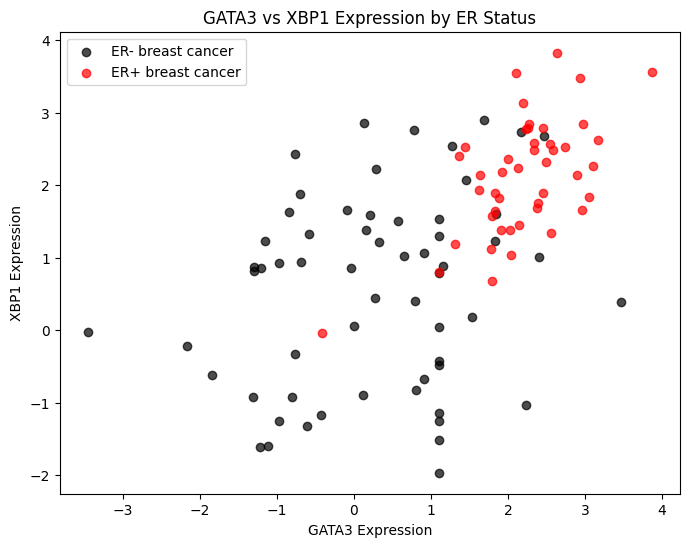

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data files
gene_expression = pd.read_csv("filtered.tsv", sep="\t")
class_labels = pd.read_csv("class.tsv", sep="\t", header=None)
gene_info = pd.read_csv("columns.tsv", sep="\t", comment="#")

# Get gene IDs for GATA3 and XBP1
gata3_id = " " + str(gene_info.loc[gene_info['GeneSymbol'] == 'GATA3', 'ID'].values[0])
xbp1_id = " " + str(gene_info.loc[gene_info['GeneSymbol'] == 'XBP1', 'ID'].values[0])

# Extract expression values and class labels
gata3_values = gene_expression[gata3_id].values
xbp1_values = gene_expression[xbp1_id].values
er_status = class_labels[0].values

# Create masks for ER- and ER+ samples
er_negative_mask = (er_status == 0)
er_positive_mask = (er_status == 1)

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(gata3_values[er_negative_mask], xbp1_values[er_negative_mask],
            color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(gata3_values[er_positive_mask], xbp1_values[er_positive_mask],
            color='red', alpha=0.7, label='ER+ breast cancer')

plt.xlabel("GATA3 Expression")
plt.ylabel("XBP1 Expression")
plt.title("GATA3 vs XBP1 Expression by ER Status")
plt.legend()
plt.show()


**2a)** Run PCA on the matrix and project these 2-D points on PC1



---

## **Part 2: PCA and 1D Projection - Figures 1b and 1c**

### Objective:

To apply **Principal Component Analysis (PCA)** to the 2D gene expression data and understand how PCA can reveal clearer group separation in an **unsupervised** manner.

### Step-by-Step:

1. **Why PCA?**

   * PCA identifies the directions (principal components) along which the data varies the most, independent of labels.
   * This helps uncover latent patterns and simplifies visualization.

2. **Performing PCA**:

   * Apply PCA to the matrix consisting of GATA3 and XBP1 expression values.
   * Extract:

     * **PC1** (direction of maximum variance),
     * **PC2** (orthogonal to PC1).

3. **Visualizing PCA Axes (Figure 1b)**:

   * Overlay PC1 and PC2 as arrows on the original scatter plot to show how PCA reorients the data.
   * If needed, flip PC1 to match the direction shown in the paper (ER+ should project positively).

4. **Projecting onto PC1 (Figure 1c)**:

   * Project each sample onto the PC1 axis to reduce the data to a **single dimension**.
   * Create three subplots:

     * All samples projected on PC1,
     * Only ER- samples,
     * Only ER+ samples.

5. **Biological Insight**:

   * The projection shows a clearer separation between ER+ and ER− groups along PC1.
   * This highlights the power of PCA in reducing dimensionality while preserving biologically meaningful variation.

6. **Variance Explained**:

   * Calculate and report the percentage of total variance captured by PC1.
   * A high value confirms that PC1 effectively summarizes the primary variation between groups.


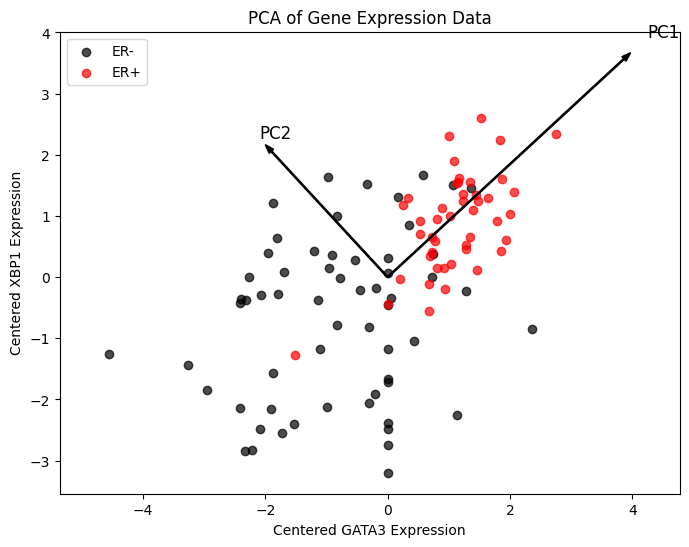

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare data matrix
expression_matrix = np.vstack((gata3_values, xbp1_values)).T

# Center the data
mean_values = np.mean(expression_matrix, axis=0)
centered_data = expression_matrix - mean_values

# Compute covariance matrix and eigenvectors
cov_matrix = np.cov(centered_data.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and vectors
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Create PCA visualization
plt.figure(figsize=(8, 6))
plt.scatter(centered_data[er_negative_mask, 0], centered_data[er_negative_mask, 1],
            color='black', alpha=0.7, label='ER-')
plt.scatter(centered_data[er_positive_mask, 0], centered_data[er_positive_mask, 1],
            color='red', alpha=0.7, label='ER+')

# Plot principal components
for i in range(2):
    plt.arrow(0, 0,
              eigenvectors[0, i] * np.sqrt(eigenvalues[i]) * 3,
              eigenvectors[1, i] * np.sqrt(eigenvalues[i]) * 3,
              color='black', width=0.02, head_width=0.1)
    plt.text(eigenvectors[0, i] * np.sqrt(eigenvalues[i]) * 3.3,
             eigenvectors[1, i] * np.sqrt(eigenvalues[i]) * 3.3,
             f'PC{i+1}', color='black', fontsize=12)

plt.xlabel("Centered GATA3 Expression")
plt.ylabel("Centered XBP1 Expression")
plt.title("PCA of Gene Expression Data")
plt.legend()
plt.axis('equal')
plt.show()

**2b)** Figure 1c.



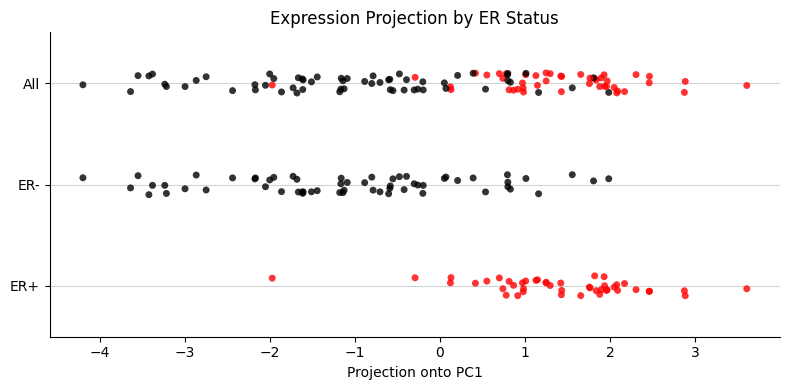

In [ ]:
import seaborn as sns

# Project data onto first principal component
pc1_vector = eigenvectors[:, 0]
pc1_projection = centered_data @ pc1_vector

# Create separate arrays for each group
all_pc1 = pc1_projection
er_neg_pc1 = pc1_projection[er_negative_mask]
er_pos_pc1 = pc1_projection[er_positive_mask]

# Create combined dataframe for plotting
projection_data = pd.DataFrame({
    'PC1': np.concatenate([all_pc1, er_neg_pc1, er_pos_pc1]),
    'Group': (['All'] * len(all_pc1) +
             ['ER-'] * len(er_neg_pc1) +
             ['ER+'] * len(er_pos_pc1)),
    'Color': (['black' if s == 0 else 'red' for s in er_status] +
             ['black'] * len(er_neg_pc1) +
             ['red'] * len(er_pos_pc1))
})

# Create strip plot
plt.figure(figsize=(8, 4))
ax = sns.stripplot(data=projection_data, x="PC1", y="Group", hue="Color",
                   palette={"black": "black", "red": "red"},
                   dodge=False, jitter=True, alpha=0.8, size=5)

# Format plot
ax.yaxis.grid(True, linestyle='-', color='lightgray')
plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.title("Expression Projection by ER Status")
plt.legend([], [], frameon=False)
sns.despine()
plt.tight_layout()
plt.show()